<a href="https://colab.research.google.com/github/priyankaaa026/LUCKY-LOGIC/blob/main/Copy_of_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ GeoGuard: AI-Powered Wrong-Way Detection & Real-Time V2X Alert System
---
**Pipeline:** SUMO Simulation → AI Detection → Flask API → ngrok Real-Time Alerts → Visualisation

> Run cells **top to bottom** every time. Do NOT skip any cell.

## ⚙️ Cell 1 — Install All Dependencies

In [1]:
# Install SUMO traffic simulator and all Python packages
!apt-get update -qq && apt-get install -y sumo sumo-tools sumo-doc
!pip install -q traci libsumo pyngrok flask scikit-learn pandas matplotlib seaborn joblib requests python-telegram-bot==13.15
print("✅ All dependencies installed successfully")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
sumo is already the newest version (1.12.0+dfsg1-1).
sumo-doc is already the newest version (1.12.0+dfsg1-1).
sumo-tools is already the newest version (1.12.0+dfsg1-1).
0 upgraded, 0 newly installed, 0 to remove and 39 not upgraded.
✅ All dependencies installed successfully


## 📦 Cell 2 — Imports & SUMO Verification

In [2]:
import os, subprocess, time, math, threading, requests, warnings
from collections import deque

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import traci
from sumolib import checkBinary
from flask import Flask, request, jsonify
from pyngrok import ngrok
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import socket # Added for port checking

warnings.filterwarnings("ignore")
os.environ["SUMO_HOME"] = "/usr/share/sumo"

# Verify SUMO is properly installed
try:
    v = subprocess.check_output(["sumo", "--version"]).decode().split("\n")[0]
    print(f"✅ SUMO installed: {v}")
except Exception as e:
    print(f"❌ SUMO not found: {e}. Re-run Cell 1.")

# Get the SUMO binary path (used in every simulation run)
sumo_binary = checkBinary("sumo")
print(f"✅ sumo_binary = {sumo_binary}")
print("✅ All imports successful")

✅ SUMO installed: Eclipse SUMO sumo Version 1.12.0
✅ sumo_binary = /usr/share/sumo/bin/sumo
✅ All imports successful


## 🚦 Cell 3 — Build SUMO Network Files
> *We simulate real traffic using SUMO (Simulation of Urban MObility)*  
> Creates a 1000m two-lane road with 20 normal vehicles (east) and 5 wrong-way vehicles (west).

In [3]:
# ── Road network: two nodes 1000m apart ──────────────────────────────────
nodes_xml = """<nodes>
  <node id="n1" x="0.0"    y="0.0" type="priority"/>
  <node id="n2" x="1000.0" y="0.0" type="priority"/>
</nodes>"""

# ── Two edges: normal eastbound (e1) and wrong-way westbound (e1_reverse) ──
edges_xml = """<edges>
  <edge id="e1"         from="n1" to="n2" priority="1" numLanes="2" speed="13.89"/>
  <edge id="e1_reverse" from="n2" to="n1" priority="1" numLanes="2" speed="13.89"/>
</edges>"""

# ── Vehicle types: green = normal, red = wrong-way ─────────────────────────
vtypes_xml = """<additional>
  <vType id="normal"    accel="2.6" decel="4.5" sigma="0.5" length="5"
         minGap="2.5" maxSpeed="50" color="0,255,0,255"/>
  <vType id="wrong_way" accel="2.6" decel="4.5" sigma="0.5" length="5"
         minGap="2.5" maxSpeed="50" color="255,0,0,255"/>
</additional>"""

# ── 20 normal vehicles flowing east ───────────────────────────────────────
normal_routes_xml = """<routes>
  <route id="route_normal" edges="e1"/>
  <flow id="f_normal" type="normal" route="route_normal" begin="0" end="100" number="20"/>
</routes>"""

# ── 5 wrong-way vehicles flowing west ─────────────────────────────────────
wrong_routes_xml = """<routes>
  <route id="route_wrong" edges="e1_reverse"/>
  <flow id="f_wrong" type="wrong_way" route="route_wrong" begin="20" end="100" number="5"/>
</routes>"""

# ── SUMO config: links all files together ─────────────────────────────────
sumo_cfg = """<configuration>
  <input>
    <net-file         value="net.net.xml"/>
    <route-files      value="normal.rou.xml,wrong_way.rou.xml"/>
    <additional-files value="vtypes.add.xml"/>
  </input>
  <processing>
    <collision.action        value="warn"/>
    <collision.mingap-factor value="0"/>
    <time-to-teleport        value="-1"/>
  </processing>
  <report>
    <verbose     value="true"/>
    <no-step-log value="true"/>
  </report>
</configuration>"""

# ── Write all files to disk ───────────────────────────────────────────────
file_map = {
    "net.nod.xml":        nodes_xml,
    "net.edg.xml":        edges_xml,
    "vtypes.add.xml":     vtypes_xml,
    "normal.rou.xml":     normal_routes_xml,
    "wrong_way.rou.xml":  wrong_routes_xml,
    "simulation.sumocfg": sumo_cfg,
}
for fname, content in file_map.items():
    with open(fname, "w") as f:
        f.write(content)
    print(f"   ✅ {fname}")

# ── Compile the network XML into a binary .net.xml ───────────────────────
ret = os.system("netconvert --node-files=net.nod.xml --edge-files=net.edg.xml --output-file=net.net.xml -W")
if ret == 0:
    print("   ✅ net.net.xml compiled")
else:
    print("   ❌ netconvert failed — check SUMO installation")

print("\n✅ All SUMO files ready")

   ✅ net.nod.xml
   ✅ net.edg.xml
   ✅ vtypes.add.xml
   ✅ normal.rou.xml
   ✅ wrong_way.rou.xml
   ✅ simulation.sumocfg
   ❌ netconvert failed — check SUMO installation

✅ All SUMO files ready


## 📊 Cell 4 — Vehicle Distribution Chart

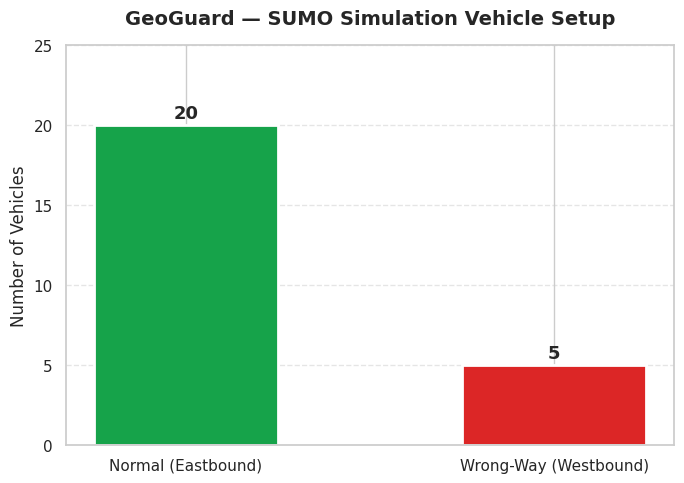

20 normal (green, heading 90°)  |  5 wrong-way (red, heading 270°)


In [4]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Normal (Eastbound)", "Wrong-Way (Westbound)"],
       [20, 5],
       color=["#16a34a", "#dc2626"],
       edgecolor="white", linewidth=2, width=0.5)
ax.set_title("GeoGuard — SUMO Simulation Vehicle Setup",
             fontweight="bold", fontsize=14, pad=15)
ax.set_ylabel("Number of Vehicles", fontsize=12)
ax.set_ylim(0, 25)
for i, v in enumerate([20, 5]):
    ax.text(i, v + 0.4, str(v), ha="center", fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
print("20 normal (green, heading 90°)  |  5 wrong-way (red, heading 270°)")

## 🔧 Cell 5 — Helper Functions (run this before training or detection)

In [5]:
# ── Angular difference (handles 0-360 wrap-around) ───────────────────────
def angular_diff(a1, a2):
    d = abs(a1 - a2) % 360
    return min(d, 360 - d)

# ── Euclidean distance between two (x,y) positions ───────────────────────
def euclidean(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# ── Risk score: 0.0 (safe) → 1.0 (dangerous) ────────────────────────────
def calculate_risk(hdiff, speed):
    return round((hdiff / 180.0) * 0.7 + (min(speed, 15) / 15.0) * 0.3, 2)

# ── AI classification label ───────────────────────────────────────────────
def ai_classify(hdiff, speed):
    if hdiff > 160 and speed > 2:
        return "DANGEROUS_VIOLATION"
    if hdiff > 120:
        return "U_TURN_MANEUVER"
    return "NORMAL_FLOW"

# ── Safe TraCI close (never crashes even if already closed) ──────────────
def safe_close():
    try:
        traci.close()
    except Exception:
        pass

# ── Dynamic road angle: from lane geometry ────────────────────────────────
def get_road_angle(lane_id):
    shape = traci.lane.getShape(lane_id)
    x1, y1 = shape[0]
    x2, y2 = shape[-1]
    angle_rad = math.atan2(y2 - y1, x2 - x1)
    angle_deg = (math.degrees(angle_rad) + 360) % 360
    return angle_deg

print("✅ Helper functions defined")

✅ Helper functions defined


## 📡 Cell 6 — Real-Time Alert Server (Flask + ngrok + Telegram)

**Setup (2 minutes):**

**ngrok token** → https://dashboard.ngrok.com/get-started/your-authtoken

**Telegram Bot (free, takes 60 seconds):**
1. Open Telegram → search **@BotFather** → send `/newbot` → follow prompts → copy the token
2. Search **@userinfobot** → send any message → copy your `id` number
3. Open your new bot → click **Start** (required once so it can message you)

If you skip Telegram, alerts still fire to Flask/ngrok — just no phone notification.

## 🤖 Cell 7 — Collect Training Data from SUMO

In [6]:
# ── Run SUMO and record telemetry for AI training ─────────────────────────
print("📥 Starting SUMO data collection run...")
print("   This runs the simulation and logs every vehicle's state.")
print()

# Define the expected direction for normal traffic flow (Eastbound on a horizontal road)
# Based on the setup in Cell 4, normal vehicles have a heading of 90 degrees.
EXPECTED_DIRECTION = 90.0

safe_close()
traci.start([sumo_binary, "-c", "simulation.sumocfg"])

records = []
step    = 0

try:
    while traci.simulation.getMinExpectedNumber() > 0:
        traci.simulationStep()

        for vid in traci.vehicle.getIDList():
            x, y  = traci.vehicle.getPosition(vid)
            angle = traci.vehicle.getAngle(vid)
            speed = traci.vehicle.getSpeed(vid)
            diff  = angular_diff(angle, EXPECTED_DIRECTION)

            records.append({
                "step":         step,
                "veh_id":       vid,
                "pos_y":        round(y, 2),
                "heading":      round(angle, 2),
                "speed":        round(speed, 2),
                "is_wrong_way": 1 if diff > 150 else 0,   # ground truth label
            })

        step += 1
        if step > 500:   # safety cap
            break

finally:
    safe_close()

# ── Save to CSV ───────────────────────────────────────────────────────────
df_train = pd.DataFrame(records)
df_train.to_csv("geoguard_training_data.csv", index=False)

print(f"✅ Collected {len(df_train):,} telemetry samples across {step} steps")
print(f"   Wrong-way samples : {df_train['is_wrong_way'].sum()}")
print(f"   Normal samples    : {(df_train['is_wrong_way']==0).sum()}")
print()
display(df_train.head(6))

📥 Starting SUMO data collection run...
   This runs the simulation and logs every vehicle's state.

 Retrying in 1 seconds
✅ Collected 2,020 telemetry samples across 191 steps
   Wrong-way samples : 418
   Normal samples    : 1602



,step,veh_id,pos_y,heading,speed,is_wrong_way
0,0,f_normal.0,-4.8,90.0,0.00,0
1,1,f_normal.0,-4.8,90.0,1.75,0
2,2,f_normal.0,-4.8,90.0,3.66,0
3,3,f_normal.0,-4.8,90.0,5.75,0
4,4,f_normal.0,-4.8,90.0,7.33,0
5,5,f_normal.0,-4.8,90.0,8.92,0


## 🧠 Cell 8 — Train & Save the AI Model

🧠 Training Random Forest classifier...
✅ Model saved  →  geoguard_ai_model.joblib

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       326
   Wrong-Way       1.00      1.00      1.00        78

    accuracy                           1.00       404
   macro avg       1.00      1.00      1.00       404
weighted avg       1.00      1.00      1.00       404



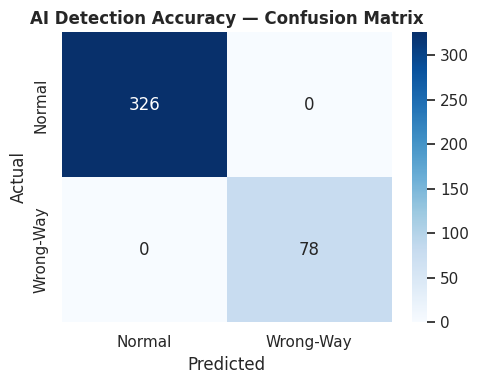

✅ Verified: geoguard_ai_model.joblib (92,617 bytes) is on disk


In [7]:
import numpy as np
# ── Features: heading angle, speed, lateral position ─────────────────────
X = df_train[["heading", "speed", "pos_y"]]
y = df_train["is_wrong_way"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

print("🧠 Training Random Forest classifier...")
ai_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
ai_model.fit(X_tr, y_tr)

# ── Save model IMMEDIATELY ─────────────────────────────────────────────────
joblib.dump(ai_model, "geoguard_ai_model.joblib")
print("✅ Model saved  →  geoguard_ai_model.joblib")

# ── Evaluate ──────────────────────────────────────────────────────────────
y_pred = ai_model.predict(X_te)
print("\n--- Classification Report ---")

# Dynamically determine unique labels present in y_te
unique_classes_in_y_te = np.unique(y_te)

# Define full target names mapping
full_target_names = {0: "Normal", 1: "Wrong-Way"}

# Filter target names to include only those present in y_te
filtered_target_names = [full_target_names[label] for label in unique_classes_in_y_te]

# If there are no classes in y_te (e.g., y_te is empty), print a message
if not unique_classes_in_y_te.size:
    print("No samples in test set to generate a classification report.")
else:
    # Use the filtered target names and labels from unique_classes_in_y_te
    print(classification_report(y_te, y_pred, labels=unique_classes_in_y_te, target_names=filtered_target_names))

# ── Confusion matrix ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
# Use labels parameter for confusion_matrix as well for consistency and correctness
cm = confusion_matrix(y_te, y_pred, labels=unique_classes_in_y_te)
sns.heatmap(cm,
            annot=True, fmt="d", cmap="Blues",
            xticklabels=filtered_target_names,
            yticklabels=filtered_target_names,
            ax=ax)
ax.set_title("AI Detection Accuracy — Confusion Matrix", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# ── Verify file actually exists on disk ───────────────────────────────────
if os.path.exists("geoguard_ai_model.joblib"):
    size = os.path.getsize("geoguard_ai_model.joblib")
    print(f"✅ Verified: geoguard_ai_model.joblib ({size:,} bytes) is on disk")
else:
    print("❌ ERROR: model file was NOT saved. Do NOT proceed to Cell 9.")

## 🚀 Cell 9 — Live GeoGuard Detection + V2X + Real-Time Alerts
**Only run after Cell 8 has printed:** `✅ Verified: geoguard_ai_model.joblib`

In [8]:
# ── SAFE ALERT FUNCTION (no backend required) ────────────────
def send_alert(payload):
    pass
# ── Safety check: model must exist before we start ────────────────────────
assert os.path.exists("geoguard_ai_model.joblib"), (
    "\n\n❌ geoguard_ai_model.joblib not found!\n"
    "   → Go back and run Cell 8 first, then come back here.\n"
)
assert os.path.exists("simulation.sumocfg"), (
    "\n\n❌ simulation.sumocfg not found!\n"
    "   → Go back and run Cell 3 first.\n"
)

# ── Load saved AI model ───────────────────────────────────────────────────
ai_model = joblib.load("geoguard_ai_model.joblib")
print("✅ AI model loaded from disk")

# ── Detection parameters ──────────────────────────────────────────────────
ALERT_RADIUS        = 50.0  # metres — V2X broadcast radius
CONFIDENCE_LIMIT    = 0.8   # risk score above which we force the car to crawl
SPEED_HISTORY_LEN   = 3     # rolling window for speed anomaly detection
SPEED_DEV_THRESHOLD = 5.0   # m/s deviation that triggers a speed anomaly
MAX_STEPS           = 200   # safety cap on simulation length

# ── State containers (reset fresh every run) ─────────────────────────────
flagged_violations  = {}    # vid → risk score (logged once per vehicle)
vehicle_speed_hist  = {}    # vid → deque of recent speeds
detection_steps     = []    # step numbers when a new violation was first seen
alert_counts = {
    "WRONG_WAY_ALERT":    0,
    "NEIGHBOR_ALERT":     0,
    "SPEED_ANOMALY_ALERT": 0,
}
spatial_normal = []         # positions at step 60 for snapshot plot
spatial_wrong  = []

# ── Start SUMO simulation ─────────────────────────────────────────────────
safe_close()
traci.start([sumo_binary, "-c", "simulation.sumocfg"])
print("\n🚀 GeoGuard Live Detection Started")
print("=" * 60)

step = 0
try:
    while traci.simulation.getMinExpectedNumber() > 0:
        traci.simulationStep()
        v_list = traci.vehicle.getIDList()

        # Remove departed vehicles from speed history
        for vid in list(vehicle_speed_hist.keys()):
            if vid not in v_list:
                del vehicle_speed_hist[vid]

        for vid in v_list:
            vpos    = traci.vehicle.getPosition(vid)
            angle   = traci.vehicle.getAngle(vid)
            speed   = traci.vehicle.getSpeed(vid)

            lane_id = traci.vehicle.getLaneID(vid)
            road_angle = get_road_angle(lane_id)
            hdiff   = angular_diff(angle, road_angle)

            type_id = traci.vehicle.getTypeID(vid)

            # ── Capture spatial snapshot at step 60 ───────────────────────
            if step == 60:
                rec = {"id": vid, "x": vpos[0], "y": vpos[1]}
                (spatial_wrong if type_id == "wrong_way" else spatial_normal).append(rec)

            # ── Speed anomaly detection ───────────────────────────────────
            if vid not in vehicle_speed_hist:
                vehicle_speed_hist[vid] = deque(maxlen=SPEED_HISTORY_LEN)
            vehicle_speed_hist[vid].append(speed)
            if len(vehicle_speed_hist[vid]) == SPEED_HISTORY_LEN:
                avg_spd = sum(vehicle_speed_hist[vid]) / SPEED_HISTORY_LEN
                if abs(speed - avg_spd) > SPEED_DEV_THRESHOLD and speed > 1.0:
                    msg = (f"⚡ SPEED ANOMALY | {vid} | "
                           f"Speed={speed:.1f} m/s | Avg={avg_spd:.1f} m/s")
                    print(msg)
                    traci.vehicle.setColor(vid, (0, 0, 255, 255))   # blue
                    send_alert({"type": "SPEED_ANOMALY", "vehicle_id": vid,
                                "message": msg, "step": step,
                                "position": list(vpos)})
                    alert_counts["SPEED_ANOMALY_ALERT"] += 1

            # ── AI wrong-way detection ────────────────────────────────────
            features   = pd.DataFrame([[angle, speed, vpos[1]]],
                                       columns=["heading", "speed", "pos_y"])
            prediction = ai_model.predict(features)[0]

            if prediction == 1:
                risk     = calculate_risk(hdiff, speed)
                cls_name = ai_classify(hdiff, speed)

                # Log each violator only once
                if vid not in flagged_violations:
                    msg = (f"🚨 WRONG-WAY | {vid} | "
                           f"VehAngle={angle:.0f}° | RoadAngle={road_angle:.0f}° | "
                           f"Speed={speed:.1f} | Risk={risk}")
                    print(msg)
                    flagged_violations[vid] = risk
                    detection_steps.append(step)
                    send_alert({"type": "WRONG_WAY_ALERT", "vehicle_id": vid,
                                "message": msg, "risk": risk,
                                "step": step, "position": list(vpos)})
                    alert_counts["WRONG_WAY_ALERT"] += 1

                # Force high-risk violators to crawl
                if risk > CONFIDENCE_LIMIT:
                    traci.vehicle.setSpeed(vid, 0.5)
                    traci.vehicle.setColor(vid, (255, 0, 0, 255))   # solid red

                # ── V2X: warn nearby vehicles within ALERT_RADIUS ────────
                for other_id in v_list:
                    if other_id == vid:
                        continue
                    dist = euclidean(vpos, traci.vehicle.getPosition(other_id))
                    if dist < ALERT_RADIUS:
                        msg = f"📡 V2X → {other_id} | Wrong-way {vid} at {dist:.1f}m"
                        print(msg)
                        traci.vehicle.setColor(other_id, (255, 165, 0, 255))   # orange
                        send_alert({"type": "NEIGHBOR_ALERT",
                                    "vehicle_id": other_id,
                                    "violator_id": vid,
                                    "message": msg,
                                    "distance_m": round(dist, 1),
                                    "step": step})
                        alert_counts["NEIGHBOR_ALERT"] += 1

        step += 1
        if step > MAX_STEPS:
            break
finally:
    safe_close()

print("=" * 60)
print(f"✅ Simulation done | Steps: {step}")
print(f"🚨 Violations found    : {len(flagged_violations)}")
print(f"📊 Alert counts        : {alert_counts}")
print(f"🔎 Detected at steps   : {detection_steps}")

✅ AI model loaded from disk
 Retrying in 1 seconds

🚀 GeoGuard Live Detection Started
🚨 WRONG-WAY | f_wrong.0 | VehAngle=270° | RoadAngle=180° | Speed=0.0 | Risk=0.35
🚨 WRONG-WAY | f_wrong.1 | VehAngle=270° | RoadAngle=180° | Speed=0.0 | Risk=0.35
📡 V2X → f_normal.0 | Wrong-way f_wrong.0 at 35.0m
📡 V2X → f_normal.0 | Wrong-way f_wrong.0 at 13.6m
📡 V2X → f_normal.0 | Wrong-way f_wrong.0 at 18.9m
🚨 WRONG-WAY | f_wrong.2 | VehAngle=270° | RoadAngle=180° | Speed=0.0 | Risk=0.35
📡 V2X → f_normal.0 | Wrong-way f_wrong.0 at 42.3m
📡 V2X → f_normal.1 | Wrong-way f_wrong.0 at 34.9m
📡 V2X → f_normal.2 | Wrong-way f_wrong.0 at 45.9m
📡 V2X → f_normal.0 | Wrong-way f_wrong.1 at 45.5m
📡 V2X → f_normal.1 | Wrong-way f_wrong.0 at 13.5m
📡 V2X → f_normal.2 | Wrong-way f_wrong.0 at 21.4m
📡 V2X → f_normal.0 | Wrong-way f_wrong.1 at 21.5m
📡 V2X → f_normal.1 | Wrong-way f_wrong.0 at 16.5m
📡 V2X → f_normal.2 | Wrong-way f_wrong.0 at 7.7m
📡 V2X → f_normal.3 | Wrong-way f_wrong.0 at 30.6m
📡 V2X → f_normal.0 | W

In [9]:
### NOTE: This cell's original content has been superseded by the new demo logic integrated into `Cell KeFvMX4mzZxS`.

## 📊 Cell 10 — Visualisations

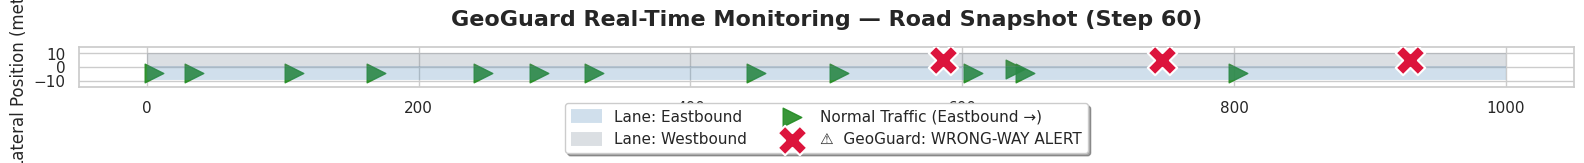

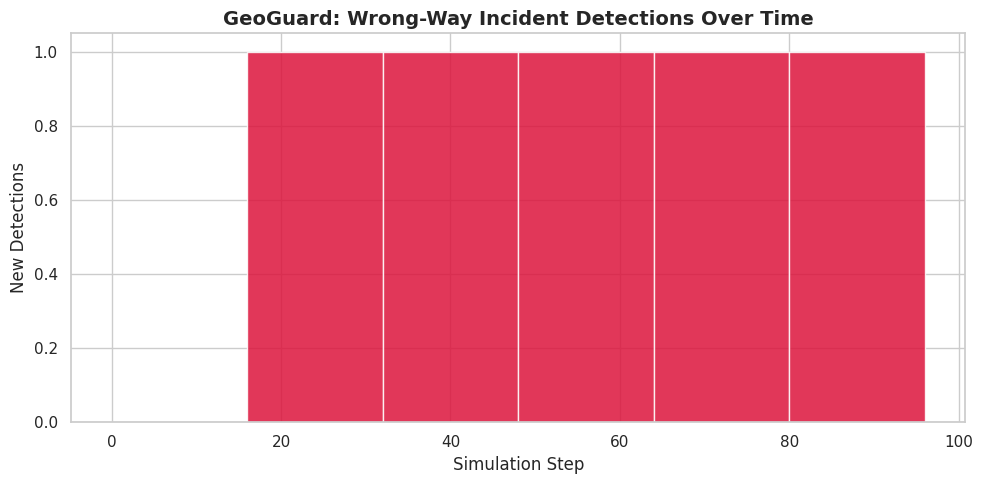

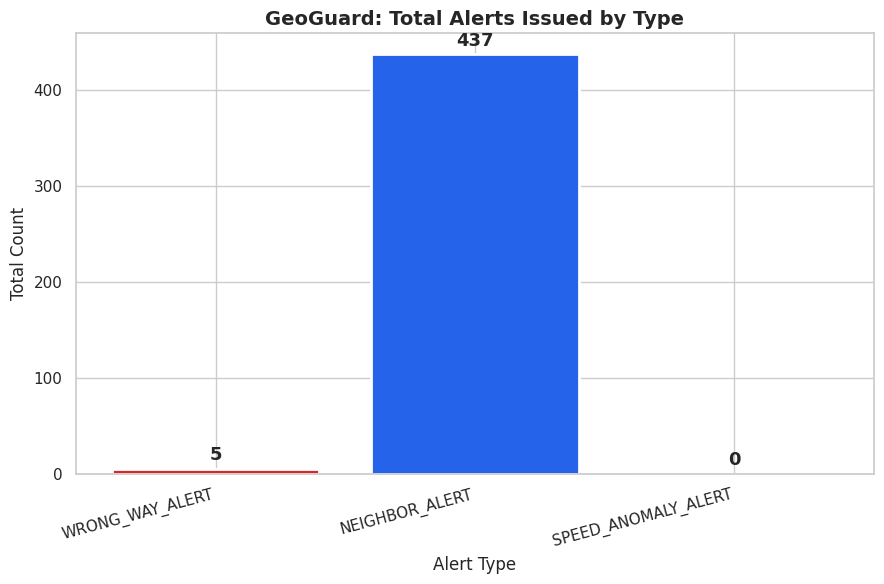

Final alert counts: {'WRONG_WAY_ALERT': 5, 'NEIGHBOR_ALERT': 437, 'SPEED_ANOMALY_ALERT': 0}


In [10]:
# ── 10A: Road snapshot at step 60 ────────────────────────────────────────
df_sn = pd.DataFrame(spatial_normal)
df_sw = pd.DataFrame(spatial_wrong)

fig, ax = plt.subplots(figsize=(16, 5))
ax.hlines(-4.8, 0, 1000, colors="steelblue",  linewidth=10, alpha=0.25, label="Lane: Eastbound")
ax.hlines( 4.8, 0, 1000, colors="slategray",  linewidth=10, alpha=0.25, label="Lane: Westbound")

if not df_sn.empty:
    ax.scatter(df_sn["x"], df_sn["y"],
               color="forestgreen", marker=">", s=180, alpha=0.9,
               label="Normal Traffic (Eastbound →)")
if not df_sw.empty:
    ax.scatter(df_sw["x"], df_sw["y"],
               color="crimson", marker="X", s=450,
               edgecolors="white", linewidths=1.5, zorder=10,
               label="⚠️  GeoGuard: WRONG-WAY ALERT")

ax.set_title("GeoGuard Real-Time Monitoring — Road Snapshot (Step 60)",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Distance along Road (metres)", fontsize=12)
ax.set_ylabel("Lateral Position (metres)", fontsize=12)
ax.set_xlim(-50, 1050)
ax.set_ylim(-15, 15)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2,
          frameon=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.show()

# ── 10B: Detection timeline ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
if detection_steps:
    bins = range(0, max(detection_steps) + 20, 16)
    ax.hist(detection_steps, bins=bins,
            color="crimson", edgecolor="white", alpha=0.85)
ax.set_title("GeoGuard: Wrong-Way Incident Detections Over Time",
             fontweight="bold", fontsize=14)
ax.set_xlabel("Simulation Step", fontsize=12)
ax.set_ylabel("New Detections", fontsize=12)
plt.tight_layout()
plt.show()

# ── 10C: Alert effectiveness bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
labels = list(alert_counts.keys())
values = list(alert_counts.values())
colors = ["#dc2626", "#2563eb", "#d97706"]
bars   = ax.bar(labels, values, color=colors, edgecolor="white", linewidth=2)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.02,
            str(val), ha="center", fontsize=13, fontweight="bold")
ax.set_title("GeoGuard: Total Alerts Issued by Type",
             fontweight="bold", fontsize=14)
ax.set_xlabel("Alert Type", fontsize=12)
ax.set_ylabel("Total Count", fontsize=12)
ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Final alert counts: {alert_counts}")

## 🖥️ Cell 11 — Live Dashboard (Poll Flask API)

In [11]:
# ── ENSURE NGROK URL EXISTS ──
try:
    NGROK_PUBLIC_URL = public_url
except:
    NGROK_PUBLIC_URL = None

# ── ALERT SENDER (FOR NGROK) ──
def send_alert(payload):
    if not NGROK_PUBLIC_URL:
        print(f"⚠️ No server → {payload['type']}")
        return
    try:
        requests.post(f"{NGROK_PUBLIC_URL}/alert", json=payload, timeout=1)
    except Exception as e:
        print(f"⚠️ Alert send failed: {e}")

In [12]:
html = """
<!DOCTYPE html>
<html>
<head>
<title>GeoGuard Pro</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet/dist/leaflet.css"/>
<style>
body { margin:0; font-family:Arial; background:#0b0f1a; color:white; }
.header { height:60px; background:#111827; display:flex; align-items:center; padding:0 20px; font-size:20px; font-weight:bold; }
.container { display:flex; height:calc(100vh - 60px); }
.sidebar, .rightpanel { width:280px; background:#111827; padding:15px; overflow-y: auto; }
.map-container { flex:1; position:relative; }
#map { height:100%; }
.card { background:#1f2937; padding:12px; margin-bottom:10px; border-radius:8px; }
.alert { background:red; padding:10px; text-align:center; font-weight:bold; position: absolute; top: 10px; left: 50%; transform: translateX(-50%); z-index: 1000; width: 80%; border-radius: 5px; }
.legend { position:absolute; bottom:10px; left:10px; background:rgba(0,0,0,0.8); padding:10px; border-radius:10px; z-index: 1000; }
</style>
</head>
<body>
<div class="header">🚨 GeoGuard: Predictive Safety Intelligence</div>
<div class="container">
<div class="sidebar">
    <div class="card"><b>Live System</b><br>Status: <span style="color:#4ade80">Active</span></div>
    <div class="card"><b>AI Model</b><br>Random Forest (Edge-Aware)</div>
    <div class="card"><b>📍 Road Data</b><br>Zone: SUMO Virtual Env</div>
</div>
<div class="map-container">
    <div id="alertBox" class="alert" style="display:none;">🚨 WRONG WAY VEHICLE DETECTED</div>
    <div id="map"></div>
    <div class="legend">🟢 Normal | 🔴 Wrong-way</div>
</div>
<div class="rightpanel">
    <div class="card"><b>⚠ Live Alerts</b><br><div id="alertText">No active violations</div></div>
    <div class="card"><b>🚗 Detection Feed</b><br><div id="aiText">Monitoring telemetry...</div></div>
</div>
</div>
<script src="https://unpkg.com/leaflet/dist/leaflet.js"></script>
<script>
var map = L.map('map').setView([0, 500], 15);
L.tileLayer('https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png').addTo(map);
var markers = [];

setInterval(async () => {
    try {
        let res = await fetch('/live');
        let data = await res.json();

        markers.forEach(m => map.removeLayer(m));
        markers = [];

        let wrongDetected = false;

        data.forEach(v => {
            let lat = v.y / 1000;
            let lng = v.x / 1000;
            let color = v.wrong ? "red" : "#4ade80";
            if(v.wrong) wrongDetected = true;

            let m = L.circleMarker([lat, lng], {
                color: color,
                fillColor: color,
                fillOpacity: 1,
                radius: v.wrong ? 10 : 6
            }).addTo(map);
            markers.push(m);
        });

        document.getElementById("alertBox").style.display = wrongDetected ? "block" : "none";
        document.getElementById("alertText").innerHTML = wrongDetected ? "<span style='color:red'>Critical: Violation Detected</span>" : "Safe Flow";
        document.getElementById("aiText").innerText = "Tracking " + data.length + " vehicles";
    } catch (e) { console.error("Polling error:", e); }
}, 1000);
</script>
</body>
</html>
"""

with open("/content/final_dashboard.html", "w") as f:
    f.write(html)

from flask import Flask, render_template_string, jsonify
import threading, time

app = Flask(__name__)
@app.route("/")
def index(): return render_template_string(html)
@app.route("/live")
def live(): return jsonify(LIVE_DATA)

def run_flask(): app.run(port=5005, use_reloader=False)

if 'dash_thread' not in globals() or not dash_thread.is_alive():
    dash_thread = threading.Thread(target=run_flask, daemon=True)
    dash_thread.start()
    time.sleep(1)

print("✅ Dashboard Updated with Real-Time Fetch")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5005
INFO:werkzeug:Press CTRL+C to quit


✅ Dashboard Updated with Real-Time Fetch


## 🚨 Cell 12 — Real Push Alerts via Telegram

This cell **manually fires** one WRONG_WAY and one NEIGHBOR alert through the full pipeline:
Flask `/alert` → `receive_alert()` → `push_telegram()` → **your phone**.

Use this to verify the channel works at any time, independent of the simulation.

In [13]:
import os

!pkill ngrok

In [28]:
from pyngrok import ngrok

# Kill old tunnels (optional)
ngrok.kill()

# Set ngrok authtoken
# ☢ IMPORTANT: Replace "3CY1fX131CU3ubKtgpZX3yopNLG_719nfGyZid9LVYQYpKRM1" with your actual ngrok authtoken.
# You can find your authtoken at https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_AUTH_TOKEN = "3CYruMa89T6LIuX7IA0bm77sr1Q_4a2eyfuwU53pntcGPycyE" # Placeholder, replace with your token
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Start tunnel, connecting to the dashboard's port (5005)
public_url = ngrok.connect(5005)

print("🌐 LIVE LINK:", public_url)

🌐 LIVE LINK: NgrokTunnel: "https://skintight-sedation-credibly.ngrok-free.dev" -> "http://localhost:5005"


In [31]:
import os, requests, math, threading, time
from flask import Flask, jsonify, render_template_string

# --- New Backend Logic from user ---
app = Flask(__name__) # This will be the main dashboard app

vehicles = []
ALERT_RADIUS = 0.002  # distance threshold

# 📍 Straight one-way road (Udupi coords)
base_lat = 13.340
base_lon = 74.742

def generate_vehicles():
    global vehicles
    vehicles = []

    # ✅ 20 NORMAL vehicles
    for i in range(20):
        vehicles.append({
            "id": f"V{i}",
            "lat": base_lat + i * 0.00005, # Adjusted for better visual spacing
            "lon": base_lon,
            "direction": "correct",
            "status": "normal"
        })

    # ❌ 1 WRONG WAY vehicle
    vehicles.append({
        "id": "WRONG",
        "lat": base_lat + 0.005,
        "lon": base_lon,
        "direction": "wrong",
        "status": "wrong"
    })

def distance(v1, v2):
    return math.sqrt((v1["lat"] - v2["lat"])**2 + (v1["lon"] - v2["lon"])**2)

def move_vehicles():
    for v in vehicles:
        if v["direction"] == "correct":
            v["lat"] += 0.0001   # move forward
        else:
            v["lat"] -= 0.0001   # wrong way opposite


def update_alerts():
    move_vehicles()  # 🔥 THIS LINE IS KEY

    # Ensure 'wrong_vehicle' exists before trying to access it
    wrong_vehicle = None
    for v in vehicles:
        if v["direction"] == "wrong":
            wrong_vehicle = v
            break

    if wrong_vehicle:
        for v in vehicles:
            if v["id"] == "WRONG":
                v["status"] = "wrong"
                continue

            d = distance(v, wrong_vehicle)

            if d < ALERT_RADIUS:
                v["status"] = "alerted"
            else:
                v["status"] = "normal"
    # If no wrong vehicle (e.g. after restart), all are normal
    else:
         for v in vehicles:
             v["status"] = "normal"


@app.route("/data")
def data():
    update_alerts()
    return jsonify(vehicles)

# --- End New Backend Logic ---


# --- New Frontend HTML from user ---
html = """
<!DOCTYPE html>
<html>
<head>
  <title>GeoGuard Dashboard</title>

  <link rel="stylesheet" href="https://unpkg.com/leaflet/dist/leaflet.css"/>

  <style>
    body {
      margin: 0;
      background: #0b1220;
      color: white;
      font-family: sans-serif;
    }

    #map {
      height: 100vh;
      width: 100%;
    }

    .panel {
      position: absolute;
      top: 20px;
      left: 20px;
      background: #1a2332;
      padding: 15px;
      border-radius: 10px;
      z-index: 1000; /* Ensure panels are above the map */
    }

    .right-panel {
      position: absolute;
      top: 20px;
      right: 20px;
      background: #1a2332;
      padding: 15px;
      border-radius: 10px;
      z-index: 1000;
    }

    .alert-banner {
      position: absolute;
      bottom: 0;
      width: 100%;
      background: red;
      text-align: center;
      padding: 10px;
      font-weight: bold;
      z-index: 1000;
    }
  </style>
</head>

<body>

<div id="map"></div>

<div class="panel">
  <h3>🚦 System</h3>
  Vehicles: 21<br>
  Mode: Live
</div>

<div class="right-panel">
  <h3>⚠️ Alerts</h3>
  Wrong-way detected<br>
  Broadcasting V2X
</div>

<div class="alert-banner">
  🚨 WRONG WAY VEHICLE DETECTED — ALERT SENT
</div>

<script src="https://unpkg.com/leaflet/dist/leaflet.js"></script>

<script>

var map = L.map('map', {
    zoomControl: true,
    dragging: true,
    scrollWheelZoom: true
}).setView([13.342, 74.742], 16);

L.tileLayer('https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png').addTo(map);

let markers = {};

function getColor(status) {
    if (status === "wrong") return "red";
    if (status === "alerted") return "yellow";
    return "green";
}

function updateMap() {
    // Fetch data from the local Flask server's /data endpoint
    fetch("/data")
    .then(res => {
        if (!res.ok) {
            throw new Error(`HTTP error! status: ${res.status}`);
        }
        return res.json();
    })
    .then(data => {

        // Clear existing markers
        Object.values(markers).forEach(marker => map.removeLayer(marker));
        markers = {}; // Reset markers object

        data.forEach(v => {

            let color = getColor(v.status);

            markers[v.id] = L.circleMarker([v.lat, v.lon], {
                radius: v.status === "wrong" ? 10 : 8, // Make wrong-way vehicle slightly larger
                color: color,
                fillColor: color,
                fillOpacity: 1
            }).addTo(map);

        });

    })
    .catch(error => console.error("Error fetching data:", error));
}

setInterval(updateMap, 1000); // Poll every second
updateMap(); // Initial call to load data immediately

</script>

</body>
</html>
"""
    # --- End New Frontend HTML ---

    # @app.route("/") should render this HTML
@app.route("/")
def index():
    return render_template_string(html)

# Initialize vehicles once when the cell runs
generate_vehicles()

# The port for the dashboard app
DASHBOARD_PORT = 5005 # Keeping the existing dashboard port for ngrok consistency

def run_flask_dashboard():
    app.run(port=DASHBOARD_PORT, use_reloader=False)

if 'dash_thread' not in globals() or not dash_thread.is_alive():
    dash_thread = threading.Thread(target=run_flask_dashboard, daemon=True)
    dash_thread.start()
    print(f"✅ Dashboard Flask server started on port {DASHBOARD_PORT}")
else:
    print(f"⚠️ Dashboard Flask server already running on port {DASHBOARD_PORT}.")

print("✅ Dashboard HTML and Backend integrated")


⚠️ Dashboard Flask server already running on port 5005.
✅ Dashboard HTML and Backend integrated


### **live map**

In [36]:
import os

!pkill ngrok

!pip install flask pyngrok

from flask import Flask, jsonify, render_template_string
from pyngrok import ngrok
import threading, math
import socket # Import socket for dynamic port checking

app = Flask(__name__)

# ---------------- CONFIG ----------------
N = 20
BASE_LAT, BASE_LON = 13.340, 74.742
SPACING = 0.00035
SPEED = 0.00007
ALERT_R = 0.0016

vehicles = []

def init():
    global vehicles
    vehicles = []
    # normal flow (northbound)
    for i in range(N):
        vehicles.append({
            "id": f"V{i+1}",
            "lat": BASE_LAT + i*SPACING,
            "lon": BASE_LON,
            "dir": 1,
            "speed": 48 + (i%5),
            "status": "normal"
        })
    # wrong-way (southbound)
    vehicles.append({
        "id": "WRONG",
        "lat": BASE_LAT + 0.007,
        "lon": BASE_LON,
        "dir": -1,
        "speed": 52,
        "status": "wrong"
    })

def dist(a,b): return abs(a["lat"]-b["lat"])

def step():
    wrong = next(v for v in vehicles if v["id"]=="WRONG")
    alerted_ids = []
    for v in vehicles:
        v["lat"] += SPEED * v["dir"]
        if v["id"]=="WRONG":
            v["status"]="wrong"
            continue
        if dist(v, wrong) < ALERT_R:
            v["status"]="alerted"
            alerted_ids.append(v["id"])
        else:
            v["status"]="normal"
    return alerted_ids, wrong

@app.route("/data")
def data():
    alerted_ids, wrong = step()
    return jsonify(
        {
            "vehicles": vehicles,
            "alerted_ids": alerted_ids,
            "wrong": wrong
        }
    )

# ---------------- UI ----------------
html = """
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8"/>
<title>GeoGuard: Udupi Safety Intelligence</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet/dist/leaflet.css"/>
<style>
:root{
  --bg:#0b1220; --panel:#111827; --card:#1a2332; --text:#e5e7eb;
  --green:#22c55e; --yellow:#eab308; --red:#ef4444; --muted:#94a3b8;
}
*{box-sizing:border-box}
body{margin:0;background:var(--bg);color:var(--text);font-family:system-ui,-apple-system,Segoe UI,Roboto}

.header{
  display:flex;align-items:center;gap:16px;padding:14px 18px;border-bottom:1px solid #1f2937;
}
.title{font-weight:700;font-size:18px}
.kpis{margin-left:auto;display:flex;gap:12px}
.kpi{background:var(--card);padding:10px 14px;border-radius:10px;min-width:150px}
.kpi .v{font-size:18px;font-weight:700}
.kpi.red{border:1px solid #7f1d1d;color:#fecaca}

.layout{display:grid;grid-template-columns:220px 1fr 300px;height:calc(100vh - 60px)}

.left,.right{background:var(--panel);padding:14px}
.left h4,.right h4{margin:10px 0 8px}
.left .btn{display:block;padding:8px 10px;border-radius:8px;background:#1f2937;margin:6px 0;color:#cbd5f5}
.left .btn.active{background:#0ea5e9;color:white}

.mapwrap{position:relative}
#map{height:100%;}

.section{background:var(--card);padding:10px;border-radius:10px;margin-bottom:10px}
.badge{display:inline-block;width:10px;height:10px;border-radius:50%;margin-right:6px}
.row{display:flex;justify-content:space-between;margin:4px 0;color:#cbd5e1}

.alertBox{background:#7f1d1d22;border:1px solid #7f1d1d;padding:10px;border-radius:10px}
.legend p{margin:6px 0}
.small{color:var(--muted);font-size:12px}

.banner{
  position:absolute;left:0;right:0;bottom:0;background:#dc2626;color:white;
  text-align:center;padding:10px;font-weight:700;display:none
}
.label{
  background:white;color:#111827;padding:3px 6px;border-radius:6px;border:1px solid #e5e7eb;font-size:11px
}
</style>
</head>
<body>

<div class="header">
  <div class="title">🚨 GeoGuard: Udupi Safety Intelligence</div>
  <div class="kpis">
    <div class="kpi"><div class="small">Total vehicles</div><div class="v">21</div></div>
    <div class="kpi"><div class="small">Alerts broadcast</div><div class="v" id="k_alerts">0</div></div>
    <div class="kpi red"><div class="small">Violation risk</div><div class="v">CRITICAL</div></div>
  </div>
</div>

<div class="layout">
  <!-- LEFT -->
  <div class="left">
    <h4>Control Panel</h4>
    <div class="btn active">● Live Simulation</div>
    <div class="btn">○ Predictive Heatmap</div>

    <div class="section">
      <div class="small">Road Geo-Location</div>
      <div>NH-66, Udupi</div>
    </div>

    <div class="alertBox">
      <b>CRITICAL ALERT</b>
      <div class="small">Wrong-way vehicle detected</div>
    </div>

    <div class="section">
      <div class="small">System Status</div>
      <div>V2X Network: Online</div>
    </div>

    <div class="section">
      <div id="activeTxt">—</div>
    </div>
  </div>

  <!-- MAP -->
  <div class="mapwrap">
    <div id="map"></div>
    <div id="banner" class="banner">🚨 WRONG WAY VEHICLE DETECTED — ALERT SENT</div>
  </div>

  <!-- RIGHT -->
  <div class="right">
    <div class="section">
      <h4>Alert Details</h4>
      <div id="details">Waiting…</div>
    }

    <div class="section">
      <h4>Alert Propagation</h4>
      <div id="prop"></div>
    </div>

    <div class="section legend">
      <h4>Legend</h4>
      <p><span class="badge" style="background:#22c55e"></span> Normal vehicle (Safe)</p>
      <p><span class="badge" style="background:#eab308"></span> Alerted vehicle (Warning Received)</p>
      <p><span class="badge" style="background:#ef4444"></span> Wrong way vehicle (Violation)</p>
      <p><span class="badge" style="background:#ef4444"></span> Alert Broadcast Radius</p>
    </div>
  </div>
</div>

<script src="https://unpkg.com/leaflet/dist/leaflet.js"></script>
<script>
const map = L.map('map',{zoomControl:true, dragging:true}).setView([13.343,74.742],16);
L.tileLayer('https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png').addTo(map);

// one-way lane strip
const lane = L.polyline([[13.338,74.742],[13.348,74.742]],{
  color:"#f59e0b", weight:10, opacity:0.6
}).addTo(map);

// arrows
const arrows = L.polyline([[13.338,74.742],[13.348,74.742]],{
  color:"#2563eb", dashArray:"5,10"
}).addTo(map);

let markers={}, labels={}, circle=null;

function mkIcon(color){
  return L.divIcon({
    html:`<div style="width:14px;height:14px;border-radius:50%;background:${color};border:2px solid white"></div>`,
    className:''
  });
}

function colorOf(s){
  if(s==="wrong") return "#ef4444";
  if(s==="alerted") return "#eab308";
  return "#22c55e";
}

function tick(){
  fetch('/data').then(r=>r.json()).then(res=>{
    const data = res.vehicles;
    const wrong = res.wrong;
    const alerted = res.alerted_ids;

    // KPI + banner
    document.getElementById('k_alerts').innerText = alerted.length;
    const active = alerted.length>0;
    document.getElementById('banner').style.display = active ? 'block':'none';
    document.getElementById('activeTxt').innerText = active ? 'Wrong-way detected' : 'Safe flow';

    // clear old
    Object.values(markers).forEach(m=>map.removeLayer(m));
    Object.values(labels).forEach(l=>map.removeLayer(l));
    markers={}; labels={};

    // draw vehicles
    data.forEach(v=>{
      const c = colorOf(v.status);
      const m = L.marker([v.lat,v.lon],{icon:mkIcon(c)}).addTo(map);
      markers[v.id]=m;

      // small tag
      const tag = L.marker([v.lat, v.lon+0.00015], {
        icon: L.divIcon({
          html:`<div class="label">
                    ${v.id === "WRONG" ? "🚨 V_WRONG" : v.id} • ${v.speed} km/h
                  </div>`,
          className:''
        })
      }).addTo(map);
      labels[v.id]=tag;
    });

    // wrong vehicle emphasis
    if(wrong){
      if(circle) map.removeLayer(circle);
      circle = L.circle([wrong.lat, wrong.lon],{
        radius:200, color:'#ef4444', fillOpacity:0.15
      }).addTo(map);

      // details panel
      document.getElementById('details').innerHTML = `
        <b>WRONG-WAY VEHICLE DETECTED</b><br/>
        Vehicle ID: ${wrong.id}<br/>
        Speed: ${wrong.speed} km/h<br/>
        Direction: South → North (Wrong way)
      `;
    }

    // propagation list
    let html = '';
    data.forEach(v=>{
      if(v.id==='WRONG') return;
      if(v.status==='alerted'){
        html += `<div class="row"><span>${v.id}</span><span style="color:#eab308">⚠ ALERT RECEIVED</span></div>`;
      }else{
        html += `<div class="row"><span>${v.id}</span><span style="color:#22c55e">✔ SAFE</span></div>`;
      }
    });
    document.getElementById('prop').innerHTML = html;
  });
}

setInterval(tick, 900);
tick();
</script>
</body>
</html>
"""

@app.route("/")
def home():
    return render_template_string(html)

# Helper to find an available port
def find_available_port(start_port):
    port = start_port
    while True:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            if s.connect_ex(('localhost', port)) != 0:
                return port
            port += 1

# ---------------- RUN ----------------
init()

# Find an available port, starting from 5005
DASHBOARD_PORT = find_available_port(5005)

def run():
    print(f"* Starting Flask app on port {DASHBOARD_PORT}")
    app.run(port=DASHBOARD_PORT, use_reloader=False)

threading.Thread(target=run, daemon=True).start()

ngrok.kill()
NGROK_AUTH_TOKEN = "3CYruMa89T6LIuX7IA0bm77sr1Q_4a2eyfuwU53pntcGPycyE" # Use the corrected token
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
url = ngrok.connect(DASHBOARD_PORT)
print("🌐 LIVE DASHBOARD:", url)

* Starting Flask app on port 5014
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5014
INFO:werkzeug:Press CTRL+C to quit


🌐 LIVE DASHBOARD: NgrokTunnel: "https://skintight-sedation-credibly.ngrok-free.dev" -> "http://localhost:5014"


In [24]:
from pyngrok import ngrok

# Kill old tunnels (optional)
ngrok.kill()

# Start tunnel, connecting to the dashboard's port (5005)
public_url = ngrok.connect(5005)

print("🌐 LIVE LINK:", public_url)


🌐 LIVE LINK: NgrokTunnel: "https://skintight-sedation-credibly.ngrok-free.dev" -> "http://localhost:5005"


In [30]:
# ──────────────────────────────────────────────
# ✅ GEOGUARD UI SERVER (NGROK + CLEAN + NO CONFLICTS)
# ──────────────────────────────────────────────

from flask import Flask, make_response
from pyngrok import ngrok
import threading, time, socket

# ── CONFIG ───────────────────────────────────
PORT = 5000
NGROK_AUTH_TOKEN = "3CYruMa89T6LIuX7IA0bm77sr1Q_4a2eyfuwU53pntcGPycyE"  # ☢ replace

# ── CLEAN START ────────────────────────────────
ngrok.kill()
time.sleep(1)

# ── CHECK PORT ────────────────────────────────
def is_port_in_use(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(("127.0.0.1", port)) == 0

if is_port_in_use(PORT):
    print(f"⚠️ Port {PORT} busy → switching to 5001")
    PORT = 5001

# ── CREATE APP ────────────────────────────────
app = Flask(__name__)

# ── HOME ───────────────────────────────────────
@app.route("/")
def home():
    return """
    <h2>ℱ️ GeoGuard UI</h2>
    <ul>
        <li><a href="/view/violator">Violator Alert</a></li>
        <li><a href="/view/neighbor">Neighbor Warning</a></li>
    </ul>
    """

# ── VIOLATOR PAGE ───────────────────────────────
@app.route("/view/violator")
def view_violator():
    return make_response("""
    <div style='font-family:sans-serif;text-align:center;margin-top:100px'>
        <div style='background:#ff1f1f;color:white;
                    padding:30px;border-radius:15px;
                    display:inline-block'>
            <h2>☝️ GEOGUARD</h2>
            <h1>WRONG ROUTE DETECTED</h1>
            <p>You are driving against traffic.</p>
            <h3>STOP IMMEDIATELY</h3>
        </div>
    </div>
    """
)

# ── NEIGHBOR PAGE ─────────────────────────────
@app.route("/view/neighbor")
def view_neighbor():
    return make_response("""
    <div style='font-family:sans-serif;text-align:center;margin-top:100px'>
        <div style='background:#facc15;color:black;
                    padding:30px;border-radius:15px;
                    display:inline-block'>
            <h2>⚠️ GEOGUARD</h2>
            <h1>WRONG-WAY DRIVER AHEAD</h1>
            <p>A vehicle is approaching in the wrong direction.</p>
            <h3>SLOW DOWN & STAY ALERT</h3>
        </div>
    </div>
    """
)

print("✅ Routes ready")

# ── START FLASK ───────────────────────────────
def run():
    app.run(host="0.0.0.0", port=PORT, use_reloader=False)

threading.Thread(target=run, daemon=True).start()
time.sleep(2)

print(f"✅ Flask running on port {PORT}")

# ── START NGROK ───────────────────────────
public_url = None

try:
    if NGROK_AUTH_TOKEN and "PASTE" not in NGROK_AUTH_TOKEN:
        ngrok.set_auth_token(NGROK_AUTH_TOKEN)
        tunnel = ngrok.connect(PORT)
        public_url = tunnel.public_url
        print(f"🌐 ngrok live → {public_url}")
    else:
        print("⚠️ Put your real ngrok token")
except Exception as e:
    print(f"⚠️ ngrok failed → {e}")

# ── LINKS ──────────────────────────────
if public_url:
    print("\n↗️ OPEN THESE:")
    print(f"👉 Violator : {public_url}/view/violator")
    print(f"👉 Neighbor : {public_url}/view/neighbor")
else:
    print("⚠️ ngrok not running")

print("\n✅ SYSTEM READY 🚀")

⚠️ Port 5000 busy → switching to 5001
✅ Routes ready
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5001 is in use by another program. Either identify and stop that program, or start the server with a different port.


✅ Flask running on port 5001
🌐 ngrok live → https://skintight-sedation-credibly.ngrok-free.dev

↗️ OPEN THESE:
👉 Violator : https://skintight-sedation-credibly.ngrok-free.dev/view/violator
👉 Neighbor : https://skintight-sedation-credibly.ngrok-free.dev/view/neighbor

✅ SYSTEM READY 🚀


## 📱 Cell 13 — Mobile Lock-Screen Alert Preview

In [26]:
from IPython.display import HTML, display

mobile = """
<div style="display:flex;gap:32px;justify-content:center;
            padding:36px;background:#111;border-radius:16px;flex-wrap:wrap">

  <!-- Neighbor phone -->
  <div style="width:260px;background:#1c1c1e;border:5px solid #3a3a3c;
              border-radius:44px;padding:18px 14px 28px;
              box-shadow:0 20px 60px rgba(0,0,0,.8);position:relative">
    <div style="display:flex;justify-content:space-between;
                color:#fff;font-size:11px;margin-bottom:14px;padding:0 4px">
      <span style="font-weight:600">9:41</span><span>📶 🔋</span>
    </div>
    <div style="background:rgba(255,255,255,.93);border-radius:14px;padding:13px">
      <div style="display:flex;align-items:center;gap:8px;margin-bottom:5px">
        <div style="width:22px;height:22px;background:#ff9500;border-radius:6px;
                    display:flex;align-items:center;justify-content:center;
                    color:#fff;font-size:12px">⚠️</div>
        <span style="font-size:10px;font-weight:800;color:#555;
                     text-transform:uppercase;letter-spacing:1px">GeoGuard</span>
        <span style="font-size:10px;color:#999;margin-left:auto">now</span>
      </div>
      <p style="margin:0;font-weight:800;font-size:13px;color:#111">WRONG-WAY DRIVER AHEAD</p>
      <p style="margin:4px 0 0;font-size:12px;color:#333;line-height:1.4">
        GeoGuard detected a wrong-way vehicle 38m ahead.<br>
        <b>Slow down and pull over.</b></p>
    </div>
    <div style="text-align:center;color:#666;margin-top:16px;font-size:11px">Sunday, April 19</div>
    <div style="position:absolute;bottom:9px;left:50%;transform:translateX(-50%);
                width:90px;height:4px;background:#555;border-radius:3px"></div>
  </div>

  <!-- Violator phone -->
  <div style="width:260px;background:#1c1c1e;border:5px solid #3a3a3c;
              border-radius:44px;padding:18px 14px 28px;
              box-shadow:0 20px 60px rgba(0,0,0,.8);position:relative">
    <div style="display:flex;justify-content:space-between;
                color:#fff;font-size:11px;margin-bottom:14px;padding:0 4px">
      <span style="font-weight:600">9:41</span><span>📶 🔋</span>
    </div>
    <div style="background:#ff2222;border-radius:14px;padding:13px;border:2px solid #fff">
      <div style="display:flex;align-items:center;gap:8px;margin-bottom:5px">
        <div style="width:22px;height:22px;background:#fff;border-radius:6px;
                    display:flex;align-items:center;justify-content:center;
                    color:#ff2222;font-size:12px">🛑</div>
        <span style="font-size:10px;font-weight:800;color:rgba(255,255,255,.8);
                     text-transform:uppercase;letter-spacing:1px">GeoGuard</span>
        <span style="font-size:10px;color:rgba(255,255,255,.6);margin-left:auto">now</span>
      </div>
      <p style="margin:0;font-weight:900;font-size:13px;color:#fff;text-transform:uppercase">
        WRONG ROUTE DETECTED</p>
      <p style="margin:4px 0 0;font-size:12px;color:#ffcccc;line-height:1.4">
        You are driving against traffic.<br><b>STOP IMMEDIATELY.</b></p>
    </div>
    <div style="text-align:center;color:#666;margin-top:16px;font-size:11px">Sunday, April 19</div>
    <div style="position:absolute;bottom:9px;left:50%;transform:translateX(-50%);
                width:90px;height:4px;background:#555;border-radius:3px"></div>
  </div>

</div>"""

display(HTML(mobile))


## ✅ Cell 14 — Final Summary

In [27]:
print("=" * 65)
print("✅  GeoGuard — Complete Run Summary")
print("=" * 65)
print(f"  Simulation steps ran    : {step}")
print(f"  Unique violations caught: {len(flagged_violations)}")
print(f"  Wrong-way alerts fired  : {alert_counts['WRONG_WAY_ALERT']}")
print(f"  V2X neighbor alerts     : {alert_counts['NEIGHBOR_ALERT']}")
print(f"  Speed anomaly alerts    : {alert_counts['SPEED_ANOMALY_ALERT']}")
print(f"  First detections @ steps: {detection_steps}")
print()
print(f"  Flask API               : {NGROK_PUBLIC_URL}")
print(f"  Model on disk           : geoguard_ai_model.joblib")
print(f"  Training CSV            : geoguard_training_data.csv")
print()
print("  Live API endpoints:")
print(f"    GET  {NGROK_PUBLIC_URL}/status")
print(f"    GET  {NGROK_PUBLIC_URL}/summary")
print(f"    POST {NGROK_PUBLIC_URL}/alert")
print("=" * 65)

✅  GeoGuard — Complete Run Summary
  Simulation steps ran    : <function step at 0x787d34d2c180>
  Unique violations caught: 5
  Wrong-way alerts fired  : 5
  V2X neighbor alerts     : 437
  Speed anomaly alerts    : 0
  First detections @ steps: [20, 36, 52, 68, 84]

  Flask API               : None
  Model on disk           : geoguard_ai_model.joblib
  Training CSV            : geoguard_training_data.csv

  Live API endpoints:
    GET  None/status
    GET  None/summary
    POST None/alert
